# Proyecto Modulo 6
Grupo:
- Consuelo Cordero
- Daniel Escalante
- Alex Mora
- Santiago Yunes

In [ ]:
%pip install duckdb
%pip install seaborn
%pip install matplotlib

# Lectura del dataset e importaciones

In [7]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
conexion = duckdb.connect("./db_used_cars.db")

Se crea la base de datos con las variables que se usaran para el analisis

In [9]:
conexion.query("""
CREATE TABLE IF NOT EXISTS CARROS AS 
SELECT 
    vin, 
    make_name, 
    model_name,
    city,
    year, 
    price, 
    mileage, 
    city_fuel_economy, 
    highway_fuel_economy, 
    listed_date, 
    dealer_zip, 
    latitude, 
    longitude,
    horsepower,
    is_new
FROM './used_cars_data.csv'
""")

In [10]:
conexion.query(
    """
    SELECT * FROM CARROS
    """
)

┌───────────────────┬────────────┬────────────────────┬───┬──────────┬───────────┬────────────┬─────────┐
│        vin        │ make_name  │     model_name     │ … │ latitude │ longitude │ horsepower │ is_new  │
│      varchar      │  varchar   │      varchar       │   │  double  │  double   │   double   │ boolean │
├───────────────────┼────────────┼────────────────────┼───┼──────────┼───────────┼────────────┼─────────┤
│ ZACNJABB5KPJ92081 │ Jeep       │ Renegade           │ … │  18.3988 │  -66.1582 │      177.0 │ true    │
│ SALCJ2FX1LH858117 │ Land Rover │ Discovery Sport    │ … │  18.4439 │  -66.0785 │      246.0 │ true    │
│ JF1VA2M67G9829723 │ Subaru     │ WRX STI            │ … │  18.3467 │  -66.1098 │      305.0 │ false   │
│ SALRR2RV0L2433391 │ Land Rover │ Discovery          │ … │  18.4439 │  -66.0785 │      340.0 │ true    │
│ SALCJ2FXXLH862327 │ Land Rover │ Discovery Sport    │ … │  18.4439 │  -66.0785 │      246.0 │ true    │
│ SALYK2EX1LA261711 │ Land Rover │ Range Rover

In [11]:
duck_summary = conexion.query("SUMMARIZE SELECT * FROM CARROS")

In [12]:
duck_summary_df = duck_summary.to_df()
duck_summary_df

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,vin,VARCHAR,0,ZPBUA1ZLXLLA06790,3024934,None,None,None,None,None,3000040,0.00
1,make_name,VARCHAR,AM General,smart,101,None,None,None,None,None,3000040,0.00
2,model_name,VARCHAR,1 Series,xD,1436,None,None,None,None,None,3000040,0.00
3,city,VARCHAR,Hayward,north hills,4684,None,None,None,None,None,3000040,0.00
4,year,BIGINT,1915,2021,98,2017.728316622445,4.178701451979507,2017,2020,2020,3000040,0.00
5,price,DOUBLE,165.0,3299995.0,89665,29933.36690395028,19566.169779298372,18400.848893379738,26467.68014670778,38280.07196610149,3000040,0.00
6,mileage,DOUBLE,0.0,99999988.0,196901,31146.899743421207,74586.7452022718,5.92897389357871,8280.994336086116,43747.286172402,3000040,4.81
7,city_fuel_economy,DOUBLE,7.0,127.0,100,22.693250237667687,8.807023953135216,18.0,21.0,26.0,3000040,16.38
8,highway_fuel_economy,DOUBLE,10.0,127.0,100,29.47337025735873,7.76925208898929,24.812111251242786,28.85232502486918,33.0,3000040,16.38
9,listed_date,DATE,2010-11-03,2020-09-13,1766,None,None,None,None,None,3000040,0.00


In [13]:
conexion.query("""
PRAGMA table_info('CARROS');
""")


┌───────┬──────────────────────┬─────────┬─────────┬────────────┬─────────┐
│  cid  │         name         │  type   │ notnull │ dflt_value │   pk    │
│ int32 │       varchar        │ varchar │ boolean │  varchar   │ boolean │
├───────┼──────────────────────┼─────────┼─────────┼────────────┼─────────┤
│     0 │ vin                  │ VARCHAR │ false   │ NULL       │ false   │
│     1 │ make_name            │ VARCHAR │ false   │ NULL       │ false   │
│     2 │ model_name           │ VARCHAR │ false   │ NULL       │ false   │
│     3 │ city                 │ VARCHAR │ false   │ NULL       │ false   │
│     4 │ year                 │ BIGINT  │ false   │ NULL       │ false   │
│     5 │ price                │ DOUBLE  │ false   │ NULL       │ false   │
│     6 │ mileage              │ DOUBLE  │ false   │ NULL       │ false   │
│     7 │ city_fuel_economy    │ DOUBLE  │ false   │ NULL       │ false   │
│     8 │ highway_fuel_economy │ DOUBLE  │ false   │ NULL       │ false   │
│     9 │ li

In [14]:
conexion.query("""
SELECT COUNT(*) FROM CARROS;
""")


┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      3000040 │
└──────────────┘

In [15]:
conexion.query("""
SELECT 
    COUNT(DISTINCT vin) AS unique_vin,
    COUNT(DISTINCT make_name) AS unique_make_name,
    COUNT(DISTINCT model_name) AS unique_model_name,
    COUNT(DISTINCT city) AS unique_city,
    COUNT(DISTINCT year) AS unique_year,
    COUNT(DISTINCT price) AS unique_price,
    COUNT(DISTINCT mileage) AS unique_mileage,
    COUNT(DISTINCT city_fuel_economy) AS unique_city_fuel_economy,
    COUNT(DISTINCT highway_fuel_economy) AS unique_highway_fuel_economy,
    COUNT(DISTINCT listed_date) AS unique_listed_date,
    COUNT(DISTINCT dealer_zip) AS unique_dealer_zip,
    COUNT(DISTINCT latitude) AS unique_latitude,
    COUNT(DISTINCT longitude) AS unique_longitude,
    COUNT(DISTINCT horsepower) AS unique_horsepower,
    COUNT(DISTINCT is_new) AS unique_is_new
FROM CARROS;
""")


┌────────────┬──────────────────┬───────────────────┬───┬──────────────────┬───────────────────┬───────────────┐
│ unique_vin │ unique_make_name │ unique_model_name │ … │ unique_longitude │ unique_horsepower │ unique_is_new │
│   int64    │      int64       │       int64       │   │      int64       │       int64       │     int64     │
├────────────┼──────────────────┼───────────────────┼───┼──────────────────┼───────────────────┼───────────────┤
│    3000000 │              100 │              1429 │ … │            23241 │               455 │             2 │
├────────────┴──────────────────┴───────────────────┴───┴──────────────────┴───────────────────┴───────────────┤
│ 1 rows                                                                                  15 columns (6 shown) │
└──────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

# Realizando la imputacion de datos nulos usando la media

In [16]:
conexion.query("""
UPDATE CARROS
SET mileage = (
    SELECT AVG(mileage) FROM CARROS WHERE mileage IS NOT NULL
)
WHERE mileage IS NULL
""")

In [17]:
conexion.query("""
UPDATE CARROS
SET city_fuel_economy = (
    SELECT AVG(city_fuel_economy) FROM CARROS WHERE city_fuel_economy IS NOT NULL
)
WHERE city_fuel_economy IS NULL
""")

In [18]:
conexion.query("""
UPDATE CARROS
SET highway_fuel_economy = (
    SELECT AVG(highway_fuel_economy) FROM CARROS WHERE highway_fuel_economy IS NOT NULL
)
WHERE highway_fuel_economy IS NULL
""")


In [19]:
conexion.query("""
UPDATE CARROS
SET horsepower = (
    SELECT AVG(horsepower) FROM CARROS WHERE horsepower IS NOT NULL
)
WHERE horsepower IS NULL
""")

Verificando que ya no haya nulos

In [20]:
conexion.query("""
SELECT 
    COUNT(*) AS total,
    SUM(CASE WHEN mileage IS NULL THEN 1 ELSE 0 END) AS missing_mileage,
    SUM(CASE WHEN city_fuel_economy IS NULL THEN 1 ELSE 0 END) AS missing_city_fuel_economy,
    SUM(CASE WHEN highway_fuel_economy IS NULL THEN 1 ELSE 0 END) AS missing_highway_fuel_economy,
    SUM(CASE WHEN horsepower IS NULL THEN 1 ELSE 0 END) AS missing_horsepower
FROM CARROS
""")

┌─────────┬─────────────────┬───────────────────────────┬──────────────────────────────┬────────────────────┐
│  total  │ missing_mileage │ missing_city_fuel_economy │ missing_highway_fuel_economy │ missing_horsepower │
│  int64  │     int128      │          int128           │            int128            │       int128       │
├─────────┼─────────────────┼───────────────────────────┼──────────────────────────────┼────────────────────┤
│ 3000040 │               0 │                         0 │                            0 │                  0 │
└─────────┴─────────────────┴───────────────────────────┴──────────────────────────────┴────────────────────┘

In [21]:
conexion.query("SUMMARIZE SELECT * FROM CARROS").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,vin,VARCHAR,0,ZPBUA1ZLXLLA06790,3024934,None,None,None,None,None,3000040,0.0
1,make_name,VARCHAR,AM General,smart,101,None,None,None,None,None,3000040,0.0
2,model_name,VARCHAR,1 Series,xD,1436,None,None,None,None,None,3000040,0.0
3,city,VARCHAR,Hayward,north hills,4684,None,None,None,None,None,3000040,0.0
4,year,BIGINT,1915,2021,98,2017.728316622445,4.17870145197909,2017,2020,2020,3000040,0.0
5,price,DOUBLE,165.0,3299995.0,89665,29933.366903950293,19566.169779298314,18418.312717074696,26453.675982106222,38232.19155926996,3000040,0.0
6,mileage,DOUBLE,0.0,99999988.0,196901,31146.89974341799,72769.74389919806,6.504110438319759,13234.956269240514,41694.17888585332,3000040,0.0
7,city_fuel_economy,DOUBLE,7.0,127.0,101,22.693250237670345,8.053687355068682,18.496522330009626,22.62515645276814,25.0,3000040,0.0
8,highway_fuel_economy,DOUBLE,10.0,127.0,101,29.473370257383316,7.1046845836225145,25.0,29.47337025735873,31.999897422914902,3000040,0.0
9,listed_date,DATE,2010-11-03,2020-09-13,1766,None,None,None,None,None,3000040,0.0


# Identificacion y trabajo con Outliers

### Precios

In [22]:
conexion.query("""
WITH stats AS (
    SELECT 
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price) AS Q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price) AS Q3
    FROM CARROS
)
SELECT 
    * 
FROM CARROS, stats
WHERE price < Q1 - 1.5 * (Q3 - Q1) OR price > Q3 + 1.5 * (Q3 - Q1)
""")

┌───────────────────┬────────────┬────────────────────┬──────────────┬───┬────────────┬─────────┬─────────┬─────────┐
│        vin        │ make_name  │     model_name     │     city     │ … │ horsepower │ is_new  │   Q1    │   Q3    │
│      varchar      │  varchar   │      varchar       │   varchar    │   │   double   │ boolean │ double  │ double  │
├───────────────────┼────────────┼────────────────────┼──────────────┼───┼────────────┼─────────┼─────────┼─────────┤
│ SALYK2EX5LA275434 │ Land Rover │ Range Rover Velar  │ San Juan     │ … │      247.0 │ true    │ 18451.0 │ 38220.0 │
│ SALZL2GX4LH007593 │ Land Rover │ Range Rover Evoque │ San Juan     │ … │      296.0 │ false   │ 18451.0 │ 38220.0 │
│ ZARBAAC41FM129303 │ Alfa Romeo │ 4C                 │ Guaynabo     │ … │      237.0 │ false   │ 18451.0 │ 38220.0 │
│ SALYK2EX8LA268316 │ Land Rover │ Range Rover Velar  │ San Juan     │ … │      247.0 │ true    │ 18451.0 │ 38220.0 │
│ SALYK2EX8LA284533 │ Land Rover │ Range Rover Velar  │ 

In [23]:
conexion.query("""
WITH stats AS (
    SELECT 
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price) AS Q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price) AS Q3
    FROM CARROS
),
outliers AS (
    SELECT 
        CASE 
            WHEN price < Q1 - 1.5 * (Q3 - Q1) OR price > Q3 + 1.5 * (Q3 - Q1) THEN 'outlier'
            ELSE 'inlier'
        END AS category
    FROM CARROS, stats
)
SELECT 
    category,
    COUNT(*) AS count
FROM outliers
GROUP BY category
""")

┌──────────┬─────────┐
│ category │  count  │
│ varchar  │  int64  │
├──────────┼─────────┤
│ inlier   │ 2913934 │
│ outlier  │   86106 │
└──────────┴─────────┘

In [24]:
prices = conexion.query("SELECT price FROM CARROS").df()['price']

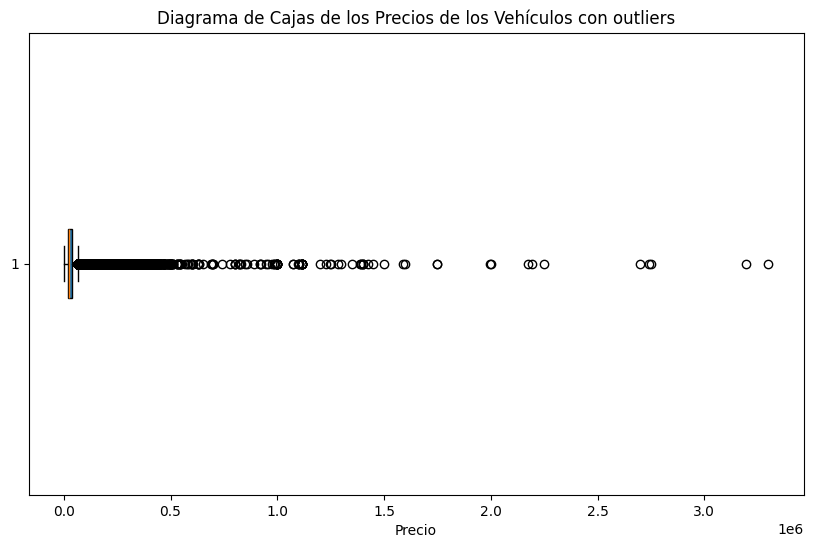

In [25]:
plt.figure(figsize=(10, 6))
plt.boxplot(prices, vert=False, patch_artist=True)
plt.title('Diagrama de Cajas de los Precios de los Vehículos con outliers')
plt.xlabel('Precio')
plt.show()

In [26]:
# Filtrar los datos para eliminar outliers
filtered_prices = conexion.query("""
WITH stats AS (
    SELECT 
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price) AS Q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price) AS Q3
    FROM CARROS
)
SELECT 
    price
FROM CARROS, stats
WHERE price >= Q1 - 1.5 * (Q3 - Q1) 
AND price <= Q3 + 1.5 * (Q3 - Q1)
""").df()['price']

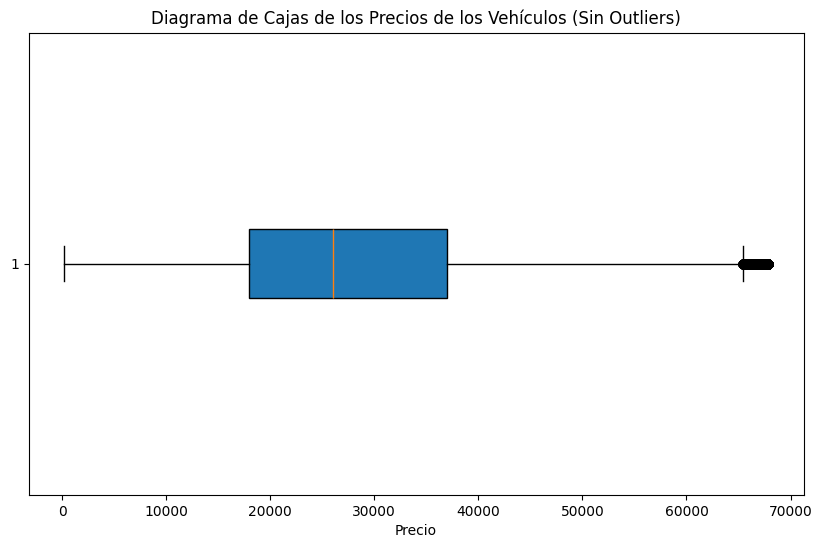

In [27]:
plt.figure(figsize=(10, 6))
plt.boxplot(filtered_prices, vert=False, patch_artist=True)
plt.title('Diagrama de Cajas de los Precios de los Vehículos (Sin Outliers)')
plt.xlabel('Precio')
plt.show()

Rango: Los bigotes que se extienden desde la caja representan el rango de precios que no son considerados outliers. En este caso, el rango de precios parece estar entre aproximadamente 5,000  y  65,000 dolares.
Podemos decir que los precios son moderados.

### Kilometraje

In [28]:
# Extraer todos los datos de millaje sin filtrar
data_mileage = conexion.query("""
SELECT mileage FROM CARROS 
WHERE mileage IS NOT NULL
""").df()['mileage']

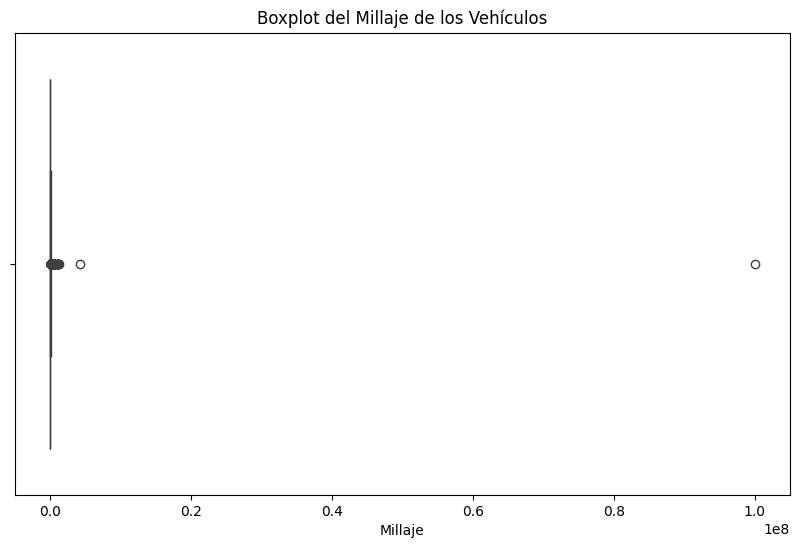

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_mileage)
plt.title('Boxplot del Millaje de los Vehículos')
plt.xlabel('Millaje')
plt.show()

In [30]:
# Calcular los cuartiles y el IQR para el millaje
q1_mileage, q3_mileage = conexion.query("""
SELECT 
    percentile_cont(0.25) WITHIN GROUP (ORDER BY mileage) AS Q1, 
    percentile_cont(0.75) WITHIN GROUP (ORDER BY mileage) AS Q3
FROM CARROS
WHERE mileage IS NOT NULL
""").fetchone()

iqr_mileage = q3_mileage - q1_mileage
lower_bound_mileage = q1_mileage - 1.5 * iqr_mileage
upper_bound_mileage = q3_mileage + 1.5 * iqr_mileage

# Identificar los outliers
outliers_mileage = conexion.query(f"""
SELECT * FROM CARROS
WHERE mileage < {lower_bound_mileage} OR mileage > {upper_bound_mileage}
""").df()

# Mostrar el número de outliers
print(f"Número de outliers en millaje: {len(outliers_mileage)}")

Número de outliers en millaje: 256274


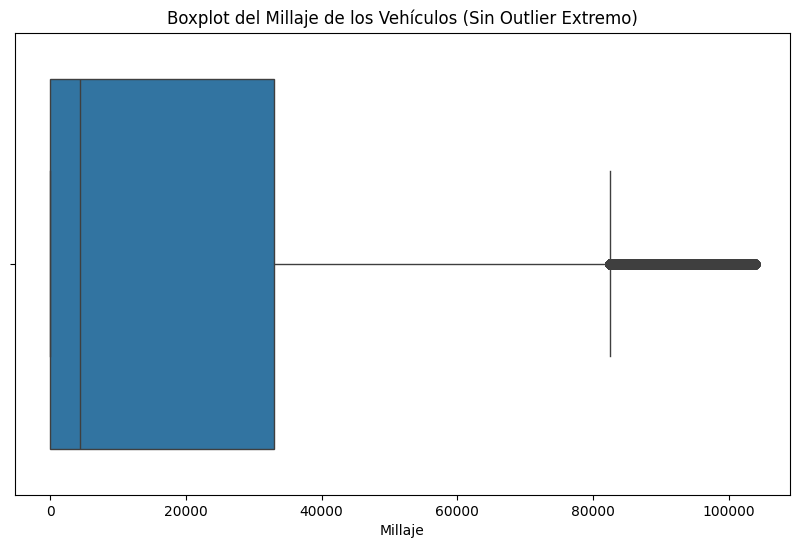

In [31]:
# Filtrar los datos para eliminar outliers extremos
data_mileage_filtered = data_mileage[data_mileage < upper_bound_mileage]

# Crear el boxplot sin el outlier extremo
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_mileage_filtered)
plt.title('Boxplot del Millaje de los Vehículos (Sin Outlier Extremo)')
plt.xlabel('Millaje')
plt.show()


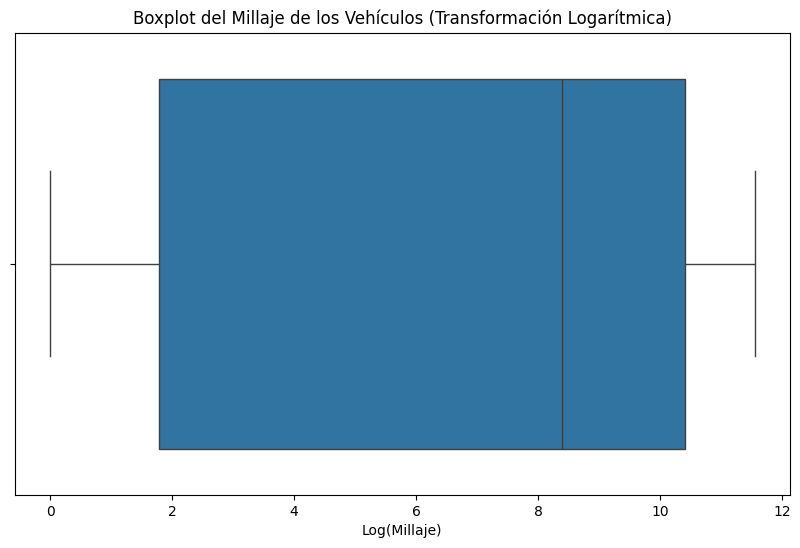

In [32]:
import numpy as np

# Aplicar transformación logarítmica
data_mileage_log = np.log1p(data_mileage_filtered)

# Crear boxplot con la transformación
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_mileage_log)
plt.title('Boxplot del Millaje de los Vehículos (Transformación Logarítmica)')
plt.xlabel('Log(Millaje)')
plt.show()

### Segmentar por año

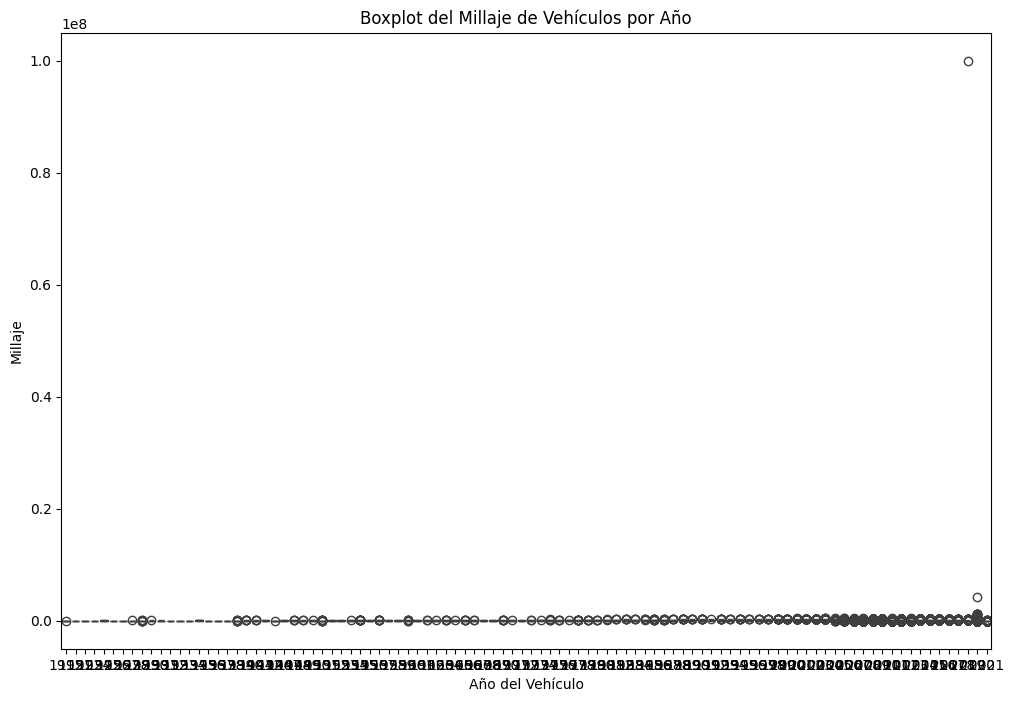

In [33]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='year', y='mileage', data=conexion.query("SELECT year, mileage FROM CARROS").df())
plt.title('Boxplot del Millaje de Vehículos por Año')
plt.xlabel('Año del Vehículo')
plt.ylabel('Millaje')
plt.show()


In [34]:
data_year = conexion.query("SELECT year, mileage FROM CARROS").df()

# Filtrar los datos para eliminar outliers extremos
data_filtered = data_year[data_year < upper_bound_mileage]

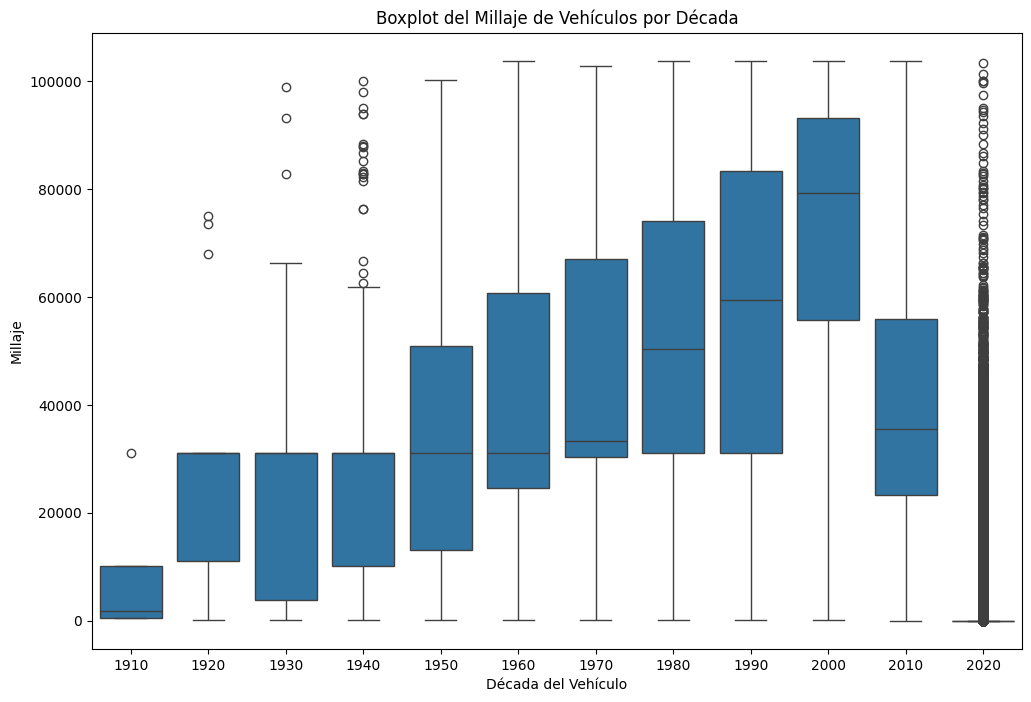

In [35]:
# Agrupar los años en décadas
data_filtered['decade'] = (data_filtered['year'] // 10) * 10

# Crear el boxplot con la nueva agrupación
plt.figure(figsize=(12, 8))
sns.boxplot(x='decade', y='mileage', data=data_filtered)
plt.title('Boxplot del Millaje de Vehículos por Década')
plt.xlabel('Década del Vehículo')
plt.ylabel('Millaje')
plt.show()

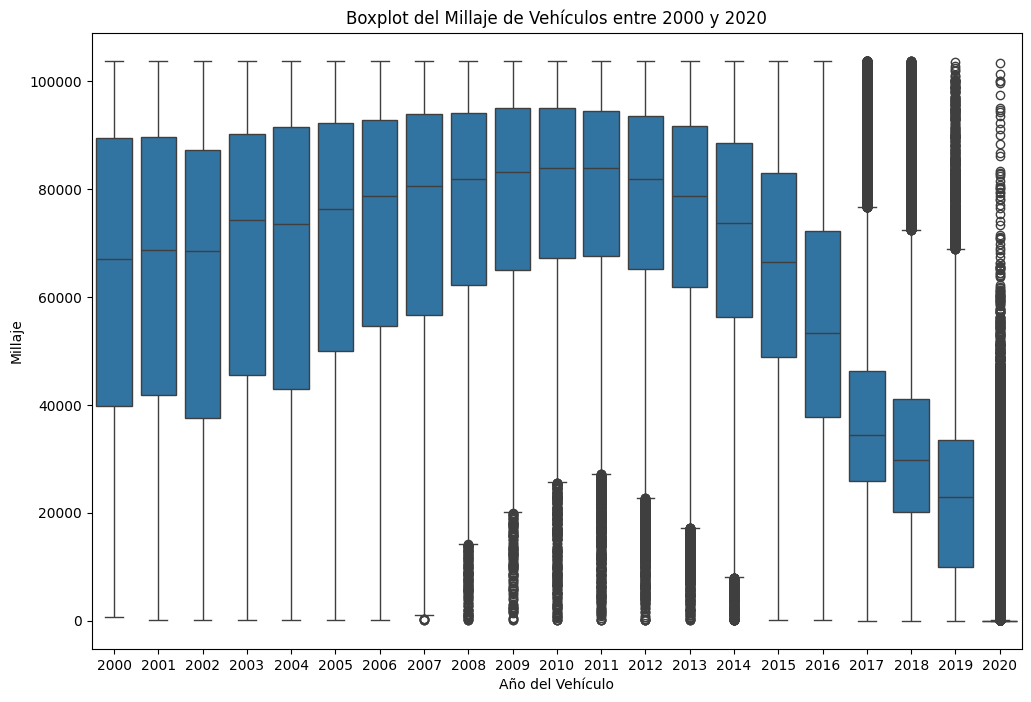

In [36]:
# Filtrar los datos para un rango de años específico
data_filtered_range = data_filtered[(data_filtered['year'] >= 2000) & (data_filtered['year'] <= 2020)]

# Crear el boxplot para ese rango de años
plt.figure(figsize=(12, 8))
sns.boxplot(x='year', y='mileage', data=data_filtered_range)
plt.title('Boxplot del Millaje de Vehículos entre 2000 y 2020')
plt.xlabel('Año del Vehículo')
plt.ylabel('Millaje')
plt.show()

* Vehículos más recientes (2016-2020): Los vehículos más nuevos tienden a tener un millaje significativamente más bajo, como es de esperar, dado que han estado en uso por menos tiempo.

* Vehículos más antiguos (2000-2008): Los vehículos de los primeros años del rango tienen un millaje relativamente alto, lo cual es coherente con el hecho de que han estado en la carretera por más tiempo.

* Hay una especie de curva en la gráfica, donde los vehículos fabricados entre 2006 y 2013 muestran un millaje ligeramente más bajo que los años anteriores y posteriores. Esto podría ser indicativo de un cambio en los patrones de uso o en la composición del mercado durante ese tiempo.

# Se buscará el top 10 de los modelos mas comprados y menos comprados

In [37]:
query ="""
SELECT 
    make_name, 
    model_name, 
    COUNT(*) AS cantidad_comprada, 
    AVG(price) AS precio_promedio 
FROM CARROS 
GROUP BY make_name, model_name 
ORDER BY cantidad_comprada DESC 
LIMIT 10
"""
mas_comprados = conexion.query(query).df()
mas_comprados

,make_name,model_name,cantidad_comprada,precio_promedio
0,Ford,F-150,128586,41194.714472
1,Chevrolet,Silverado 1500,73221,38429.906385
2,RAM,1500,69117,40533.643646
3,Chevrolet,Equinox,63341,23005.976013
4,Ford,Escape,56905,21987.239009
5,Ford,Explorer,49001,36310.871957
6,Nissan,Rogue,48470,21865.024526
7,Jeep,Grand Cherokee,45602,33619.592208
8,Toyota,Camry,43618,21187.967301
9,Honda,CR-V,43409,25074.582332


In [38]:
query = """
SELECT 
    make_name, 
    model_name, 
    COUNT(*) AS cantidad_comprada, 
    AVG(price) AS precio_promedio 
FROM CARROS 
GROUP BY make_name, model_name 
ORDER BY cantidad_comprada ASC 
LIMIT 100
"""
menos_comprados = conexion.query(query).df()
menos_comprados

,make_name,model_name,cantidad_comprada,precio_promedio
0,Datsun,210,1,6500.0
1,Buick,Somerset,1,2900.0
2,Acura,SLX,1,2999.0
3,Volkswagen,Karmann Ghia,1,13777.0
4,Mercedes-Benz,230SL,1,46900.0
...,...,...,...,...
95,Jaguar,Mark V,1,199999.0
96,Toyota,Hiace,1,12995.0
97,Alfa Romeo,1900,1,169900.0
98,Nissan,Patrol,1,5999.0


Contar Modelos Comprados Solo Una Vez

In [39]:
query = """
SELECT 
    COUNT(*) AS modelos_con_una_compra
FROM (
    SELECT 
        make_name, 
        model_name, 
        COUNT(*) AS cantidad_comprada 
    FROM CARROS 
    GROUP BY make_name, model_name 
    HAVING cantidad_comprada = 1
) AS subquery
"""
modelos_con_una_compra = conexion.query(query).df()
modelos_con_una_compra

,modelos_con_una_compra
0,175


In [40]:
query ="""
SELECT 
    make_name, 
    model_name, 
    COUNT(*) AS cantidad_comprada, 
    AVG(price) AS precio_promedio 
FROM CARROS 
GROUP BY make_name, model_name 
ORDER BY cantidad_comprada DESC 
LIMIT 20
"""
top20_comprados = conexion.query(query).df()


C:\Users\alexm\AppData\Local\Temp\ipykernel_16640\3715357914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cantidad_comprada', y='model_name', data=top20_comprados, palette='viridis')


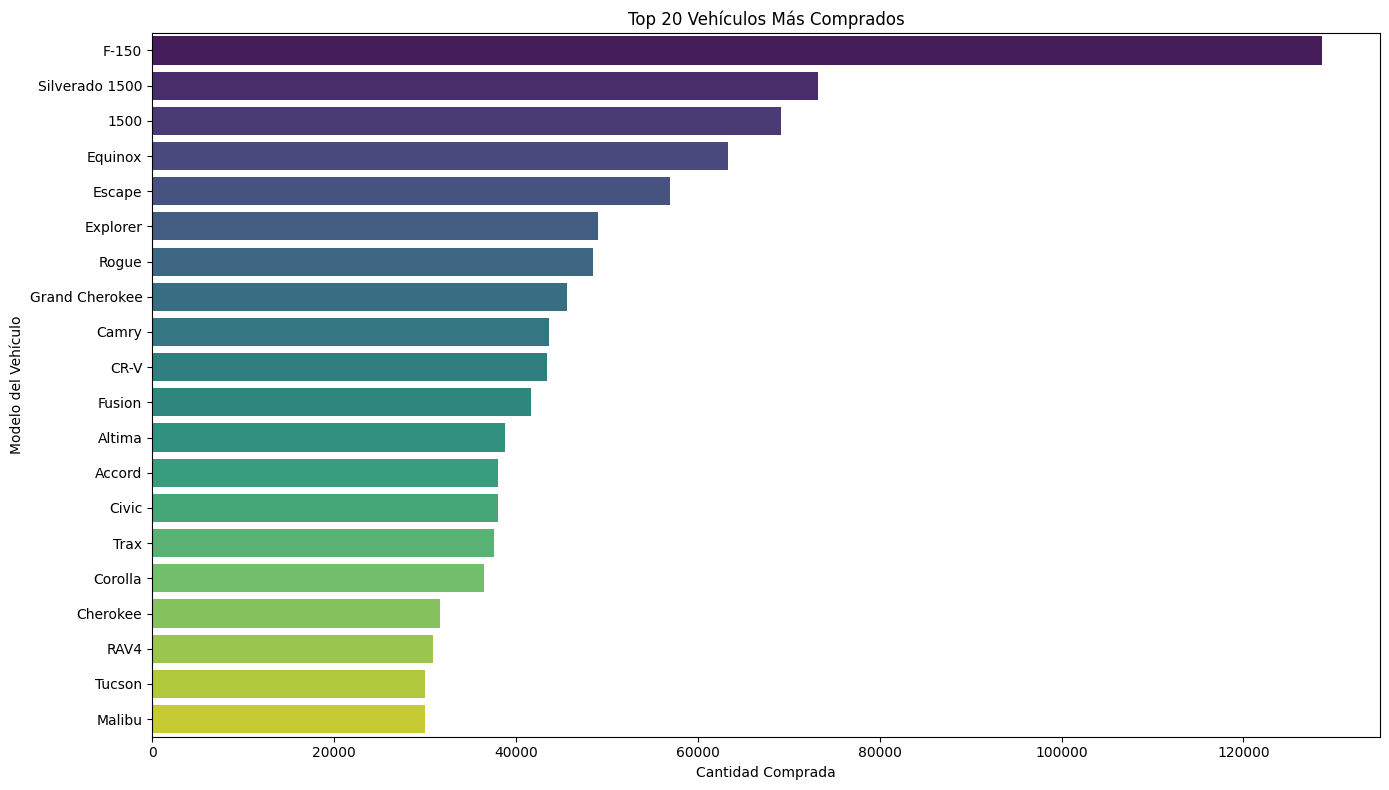

In [41]:
plt.figure(figsize=(14, 8))

sns.barplot(x='cantidad_comprada', y='model_name', data=top20_comprados, palette='viridis')

plt.title('Top 20 Vehículos Más Comprados')
plt.xlabel('Cantidad Comprada')
plt.ylabel('Modelo del Vehículo')

plt.tight_layout()
plt.show()

# Los 10 Vehículos Más Caros en los Últimos 4 Años

In [42]:
query = """
WITH filtered_data AS (
    SELECT 
        year, 
        make_name, 
        model_name, 
        MAX(price) AS price
    FROM CARROS
    WHERE year >= (SELECT MAX(year) - 3 FROM CARROS)  -- Filtrar los últimos 4 años
    GROUP BY year, make_name, model_name
),
ranked_data AS (
    SELECT 
        year, 
        make_name, 
        model_name, 
        price,
        ROW_NUMBER() OVER (PARTITION BY year ORDER BY price DESC) AS rank
    FROM filtered_data
)
SELECT 
    year,
    make_name,
    model_name,
    price
FROM ranked_data
WHERE rank <= 10
ORDER BY year, price DESC
"""
top_10_caros_por_ano = conexion.query(query).df()


C:\Users\alexm\AppData\Local\Temp\ipykernel_16640\1420969088.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y='price', data=data_year, palette='viridis')
C:\Users\alexm\AppData\Local\Temp\ipykernel_16640\1420969088.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y='price', data=data_year, palette='viridis')
C:\Users\alexm\AppData\Local\Temp\ipykernel_16640\1420969088.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y='price', data=data_year, palette='viridis')
C:\Users\alexm\AppData

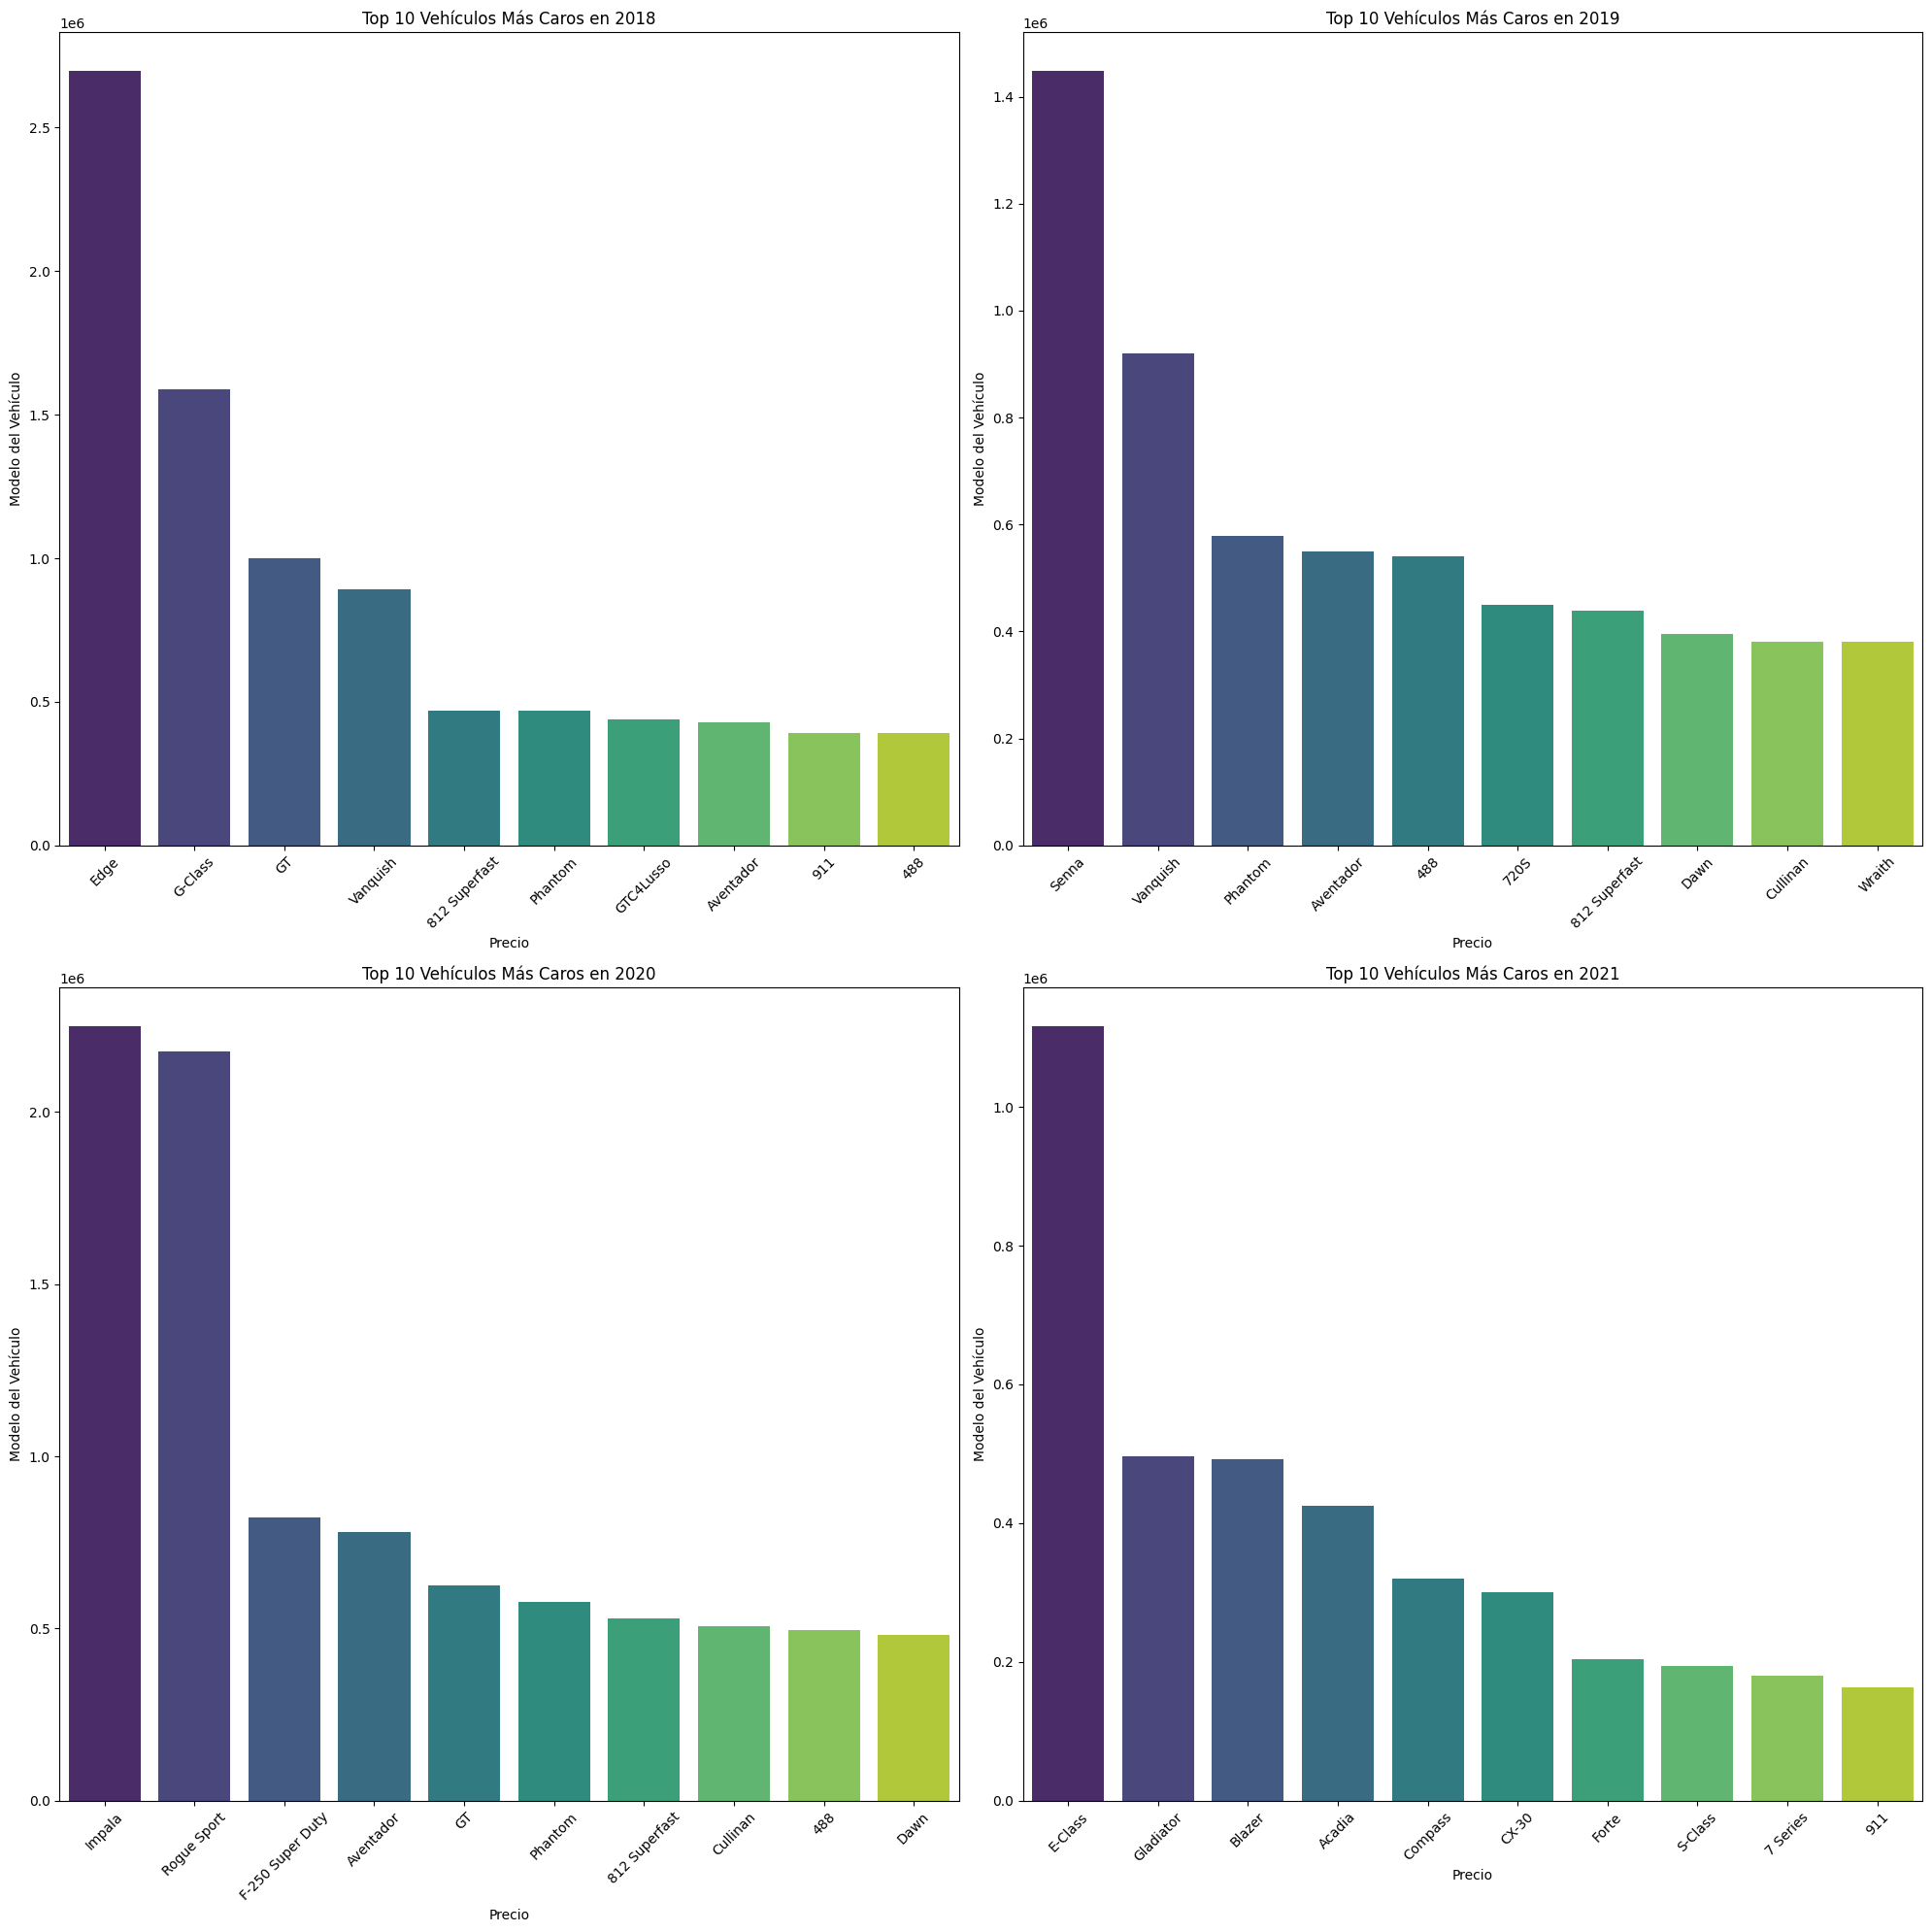

In [43]:
plt.figure(figsize=(20, 20))
years = top_10_caros_por_ano['year'].unique()

for i, year in enumerate(years, 1):
    plt.subplot(2, 2, i)
    data_year = top_10_caros_por_ano[top_10_caros_por_ano['year'] == year]
    sns.barplot(x='model_name', y='price', data=data_year, palette='viridis')
    plt.title(f'Top 10 Vehículos Más Caros en {year}')
    plt.xlabel('Precio')
    plt.ylabel('Modelo del Vehículo')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Mapa de correlaciones

In [44]:
correlation_query = """
SELECT 
    price, 
    mileage, 
    city_fuel_economy, 
    highway_fuel_economy, 
    year
FROM CARROS
"""
correlation_matrix = conexion.query(correlation_query).df().corr()
correlation_matrix

,price,mileage,city_fuel_economy,highway_fuel_economy,year
price,1.000000,-0.267126,-0.150166,-0.215951,0.355366
mileage,-0.267126,1.000000,-0.078749,-0.071985,-0.448079
city_fuel_economy,-0.150166,-0.078749,1.000000,0.940728,0.118493
highway_fuel_economy,-0.215951,-0.071985,0.940728,1.000000,0.111975
year,0.355366,-0.448079,0.118493,0.111975,1.000000


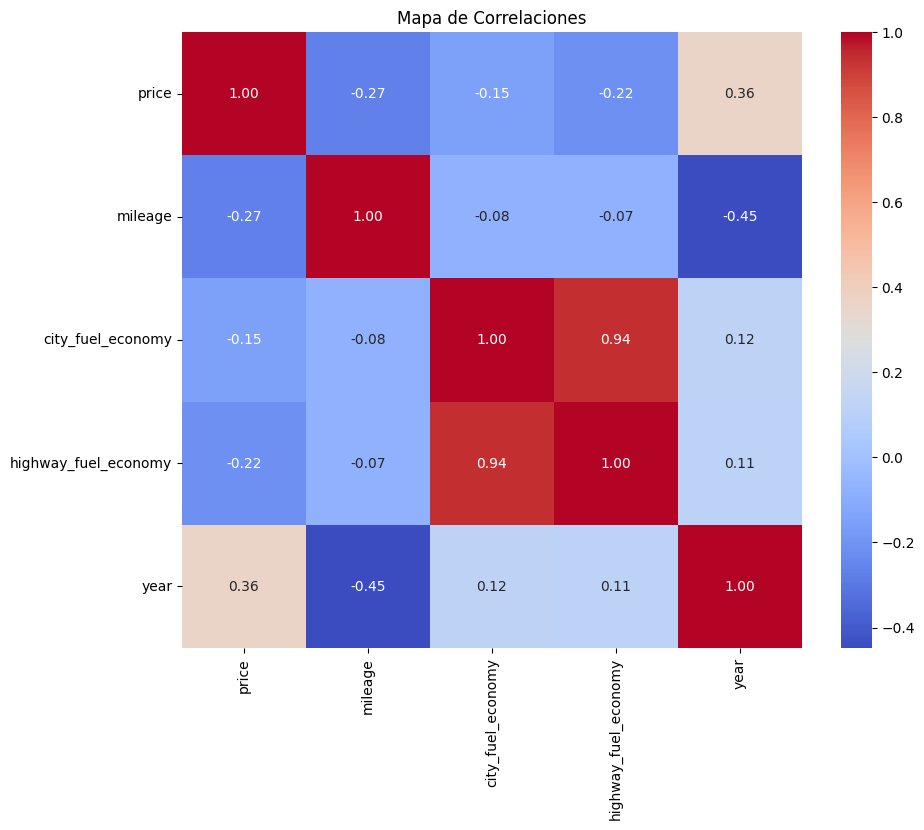

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlaciones')
plt.show()


### Correlación entre year (año) y price (precio):

* Correlación positiva moderada (+0.36).
* Los vehículos más nuevos tienden a ser más caros.
* Esto refleja que los vehículos recientes tienen menos desgaste y tecnología más moderna.

### Correlación entre mileage (millaje) y price (precio):

* Correlación negativa moderada (-0.27).
* A medida que el millaje aumenta, el precio del vehículo tiende a disminuir.
* Los vehículos con más millaje son menos valiosos debido al mayor desgaste.

### Correlación entre city_fuel_economy (economía de combustible en ciudad) y highway_fuel_economy (economía de combustible en carretera):

* Correlación positiva muy fuerte (+0.94).
* Los vehículos eficientes en ciudad también tienden a ser eficientes en carretera.
* Esto sugiere consistencia en la eficiencia de combustible en diferentes condiciones de conducción.

### Correlación entre year (año) y mileage (millaje):

* Correlación negativa moderada (-0.45).
* Los vehículos más nuevos tienden a tener menos millaje.
* Esto es lógico ya que los vehículos recientes han sido utilizados por menos tiempo.

# Distribución Geográfica de Precios por Estado

In [2]:
!pip install geopandas


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached geopandas-1.0.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached pyogrio-0.9.0-cp310-cp310-win_amd64.whl.metadata (3.9 kB)
Using cached geopandas-1.0.1-py3-none-any.whl (323 kB)
Using cached pyogrio-0.9.0-cp310-cp310-win_amd64.whl (15.9 MB)


In [45]:
import geopandas as gpd
from shapely.geometry import Point

In [46]:
query_geo = """
SELECT dealer_zip, latitude, longitude, price
FROM CARROS
WHERE latitude IS NOT NULL AND longitude IS NOT NULL
"""
geo_distribution_df = conexion.query(query_geo).df()


In [47]:
geo_distribution_df['geometry'] = geo_distribution_df.apply(lambda x: Point((x['longitude'], x['latitude'])), axis=1)
geo_gdf = gpd.GeoDataFrame(geo_distribution_df, geometry='geometry')
geo_gdf.head()

,dealer_zip,latitude,longitude,price,geometry
0,00960,18.3988,-66.1582,23141.0,POINT (-66.1582 18.3988)
1,00922,18.4439,-66.0785,46500.0,POINT (-66.0785 18.4439)
2,00969,18.3467,-66.1098,46995.0,POINT (-66.1098 18.3467)
3,00922,18.4439,-66.0785,67430.0,POINT (-66.0785 18.4439)
4,00922,18.4439,-66.0785,48880.0,POINT (-66.0785 18.4439)


In [48]:
# Cargar los datos geoespaciales de los estados de Estados Unidos
usa_states = gpd.read_file('us-states.json')
usa_states.head()

,id,name,density,geometry
0,01,Alabama,94.650,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847..."
1,02,Alaska,1.264,"MULTIPOLYGON (((-131.60202 55.11798, -131.5691..."
2,04,Arizona,57.050,"POLYGON ((-109.0425 37.00026, -109.04798 31.33..."
3,05,Arkansas,56.430,"POLYGON ((-94.47384 36.50186, -90.15254 36.496..."
4,06,California,241.700,"POLYGON ((-123.23326 42.00619, -122.37885 42.0..."


<Axes: >

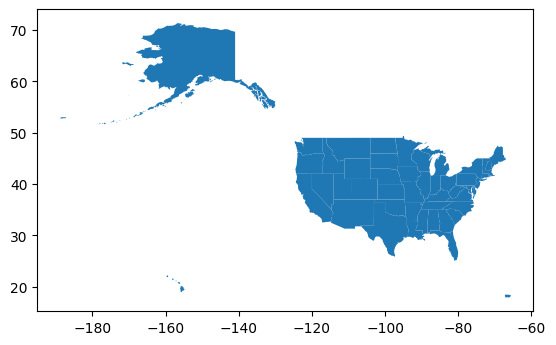

In [49]:
usa_states.plot()

In [50]:
gdfs = gpd.sjoin(usa_states,geo_gdf,how="inner")
gdfs

C:\Users\alexm\AppData\Local\Temp\ipykernel_39136\2125040141.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: None

  gdfs = gpd.sjoin(usa_states,geo_gdf,how="inner")


,id,name,density,geometry,index_right,dealer_zip,latitude,longitude,price
0,01,Alabama,94.65,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847...",1270185,36310,31.5512,-85.2525,47755.0
0,01,Alabama,94.65,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847...",1270623,36310,31.5512,-85.2525,68322.0
0,01,Alabama,94.65,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847...",1269923,36310,31.5512,-85.2525,31900.0
0,01,Alabama,94.65,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847...",1270278,36310,31.5512,-85.2525,51823.0
0,01,Alabama,94.65,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847...",1270657,36310,31.5512,-85.2525,71801.0
...,...,...,...,...,...,...,...,...,...
51,72,Puerto Rico,1082.00,"POLYGON ((-66.44834 17.98433, -66.77148 18.006...",16,00922,18.4439,-66.0785,52275.0
51,72,Puerto Rico,1082.00,"POLYGON ((-66.44834 17.98433, -66.77148 18.006...",3,00922,18.4439,-66.0785,67430.0
51,72,Puerto Rico,1082.00,"POLYGON ((-66.44834 17.98433, -66.77148 18.006...",118,00922,18.4439,-66.0785,58975.0
51,72,Puerto Rico,1082.00,"POLYGON ((-66.44834 17.98433, -66.77148 18.006...",125,00922,18.4439,-66.0785,59499.0


In [68]:
gdf_estados = gdfs.groupby("name")["price"].sum().reset_index()
gdf_estados

,name,price
0,Alabama,1.372010e+09
1,Alaska,9.777000e+04
2,Arizona,2.316661e+09
3,Arkansas,7.855765e+08
4,California,8.968050e+09
5,Colorado,1.900078e+09
6,Connecticut,9.790531e+08
7,Delaware,2.780722e+08
8,District of Columbia,2.267716e+07
9,Florida,7.031072e+09


In [69]:
gdfr = usa_states.merge(gdf_estados, on="name",how="inner")
gdfr


,id,name,density,geometry,price
0,01,Alabama,94.650,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847...",1.372010e+09
1,02,Alaska,1.264,"MULTIPOLYGON (((-131.60202 55.11798, -131.5691...",9.777000e+04
2,04,Arizona,57.050,"POLYGON ((-109.0425 37.00026, -109.04798 31.33...",2.316661e+09
3,05,Arkansas,56.430,"POLYGON ((-94.47384 36.50186, -90.15254 36.496...",7.855765e+08
4,06,California,241.700,"POLYGON ((-123.23326 42.00619, -122.37885 42.0...",8.968050e+09
5,08,Colorado,49.330,"POLYGON ((-107.91973 41.00391, -105.72895 40.9...",1.900078e+09
6,09,Connecticut,739.100,"POLYGON ((-73.05353 42.03905, -71.79931 42.022...",9.790531e+08
7,10,Delaware,464.300,"POLYGON ((-75.41409 39.80446, -75.5072 39.6839...",2.780722e+08
8,11,District of Columbia,10065.000,"POLYGON ((-77.03526 38.99387, -76.90929 38.895...",2.267716e+07
9,12,Florida,353.400,"POLYGON ((-85.49714 30.99754, -85.00421 31.003...",7.031072e+09


In [70]:
gdfr.set_index("name",inplace =True)
gdfr

,id,density,geometry,price
name,,,,
Alabama,01,94.650,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847...",1.372010e+09
Alaska,02,1.264,"MULTIPOLYGON (((-131.60202 55.11798, -131.5691...",9.777000e+04
Arizona,04,57.050,"POLYGON ((-109.0425 37.00026, -109.04798 31.33...",2.316661e+09
Arkansas,05,56.430,"POLYGON ((-94.47384 36.50186, -90.15254 36.496...",7.855765e+08
California,06,241.700,"POLYGON ((-123.23326 42.00619, -122.37885 42.0...",8.968050e+09
Colorado,08,49.330,"POLYGON ((-107.91973 41.00391, -105.72895 40.9...",1.900078e+09
Connecticut,09,739.100,"POLYGON ((-73.05353 42.03905, -71.79931 42.022...",9.790531e+08
Delaware,10,464.300,"POLYGON ((-75.41409 39.80446, -75.5072 39.6839...",2.780722e+08
District of Columbia,11,10065.000,"POLYGON ((-77.03526 38.99387, -76.90929 38.895...",2.267716e+07


In [ ]:
!pip install plotly
!pip install ipykernel
!pip install nbformat 
pip install --upgrade nbformat

In [58]:
!pip install --upgrade nbformat


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
import plotly.express as px
fig = px.choropleth_mapbox(gdfr,
                   geojson=gdfr.geometry,
                   locations=gdfr.index,
                   color_continuous_scale = [[0,"silver"],
                                 [0.2, "yellow"],
                                 [0.5,"orange"],
                                 [0.7,"brown"],
                                 [1,"red"]],
                   color="price",
                   center = {"lat":38.863666, "lon":-103.680803},
                   mapbox_style= "open-street-map" ,
                   zoom=2)
fig.update_geos(fitbounds="locations", visible=False)
fig.show()

In [72]:
gdf_estados_mean = gdfs.groupby("name")["price"].mean().reset_index()
gdfr_mean = usa_states.merge(gdf_estados_mean, on="name",how="inner")
gdfr_mean.set_index("name",inplace =True)
fig = px.choropleth_mapbox(gdfr_mean,
                   geojson=gdfr_mean.geometry,
                   locations=gdfr_mean.index,
                   color_continuous_scale = [[0,"silver"],
                                 [0.2, "yellow"],
                                 [0.5,"orange"],
                                 [0.7,"brown"],
                                 [1,"red"]],
                   color="price",
                   center = {"lat":38.863666, "lon":-103.680803},
                   mapbox_style= "open-street-map" ,
                   zoom=2)
fig.update_geos(fitbounds="locations", visible=False)
fig.show()

# Relacion Precio Kilometraje

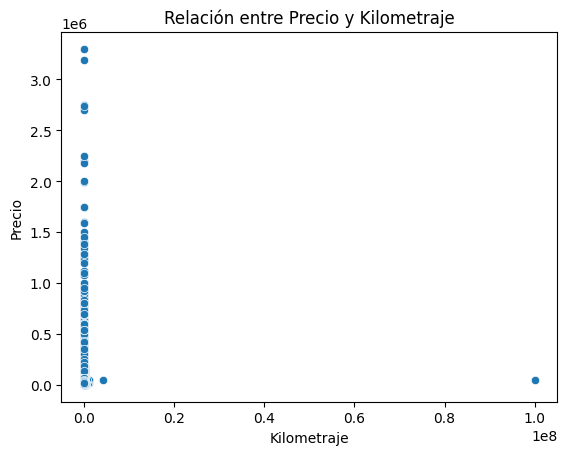

In [136]:
# Scatter Plot: Precio vs Kilometraje
scatter_query = """
SELECT 
    price, 
    mileage 
FROM CARROS 
WHERE price IS NOT NULL AND mileage IS NOT NULL
"""
scatter_data = conexion.query(scatter_query).df()

sns.scatterplot(x='mileage', y='price', data=scatter_data)
plt.title('Relación entre Precio y Kilometraje')
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

# Graficos

Relación entre price (precio) y mileage (millaje)

In [137]:
query = """
SELECT mileage, price
FROM CARROS
WHERE mileage IS NOT NULL AND price IS NOT NULL
"""

data = conexion.query(query).df()

In [138]:
print(data.columns)

Index(['mileage', 'price'], dtype='object')


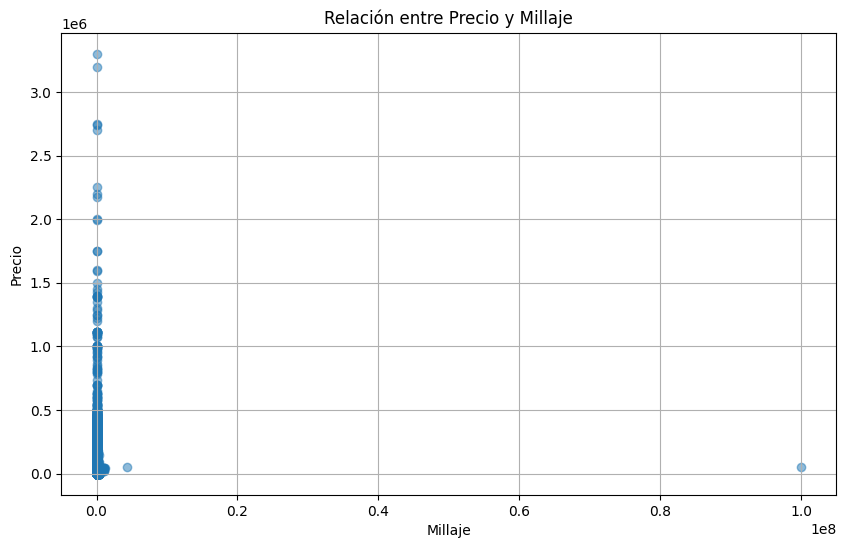

In [139]:
plt.figure(figsize=(10, 6))
plt.scatter(data['mileage'], data['price'], alpha=0.5)
plt.title('Relación entre Precio y Millaje')
plt.xlabel('Millaje')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

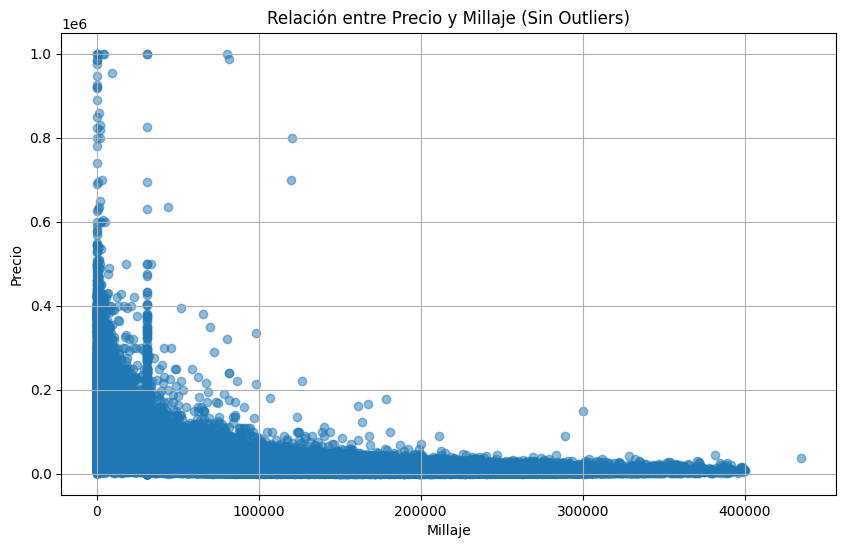

In [140]:
# Filtrar outliers en millaje y precio
data_filtered = data[(data['mileage'] < 500000) & (data['price'] < 1000000)]

plt.figure(figsize=(10, 6))
plt.scatter(data_filtered['mileage'], data_filtered['price'], alpha=0.5)
plt.title('Relación entre Precio y Millaje (Sin Outliers)')
plt.xlabel('Millaje')
plt.ylabel('Precio')
plt.grid(True)
plt.show()


* Relación Inversa entre Precio y Millaje: El gráfico muestra una relación inversa clara entre el millaje y el precio. A medida que el millaje aumenta, el precio tiende a disminuir. Los vehículos con mayor millaje generalmente se venden por un precio menor debido al mayor desgaste y uso.

* Concentración de Datos: Hay una alta concentración de puntos cerca del origen, donde muchos vehículos tienen precios bajos y millajes moderados o altos. Esto sugiere que una gran parte de los vehículos son usados con un millaje considerable y se venden a precios relativamente bajos.

* Outliers o Casos Especiales: Aunque has eliminado los outliers más extremos, todavía puedes ver algunos vehículos con millajes bajos y precios inusualmente altos. Estos podrían ser vehículos de lujo, modelos especiales, o datos atípicos que podrían merecer una revisión adicional.

* Distribución de Precios: El gráfico también sugiere que incluso con millajes altos, hay un límite en el precio que los vehículos pueden alcanzar, lo que está representado por la forma cóncava en la parte superior de la gráfica. Esto podría indicar que hay un precio máximo más allá del cual los vehículos no se venden, independientemente de su millaje.

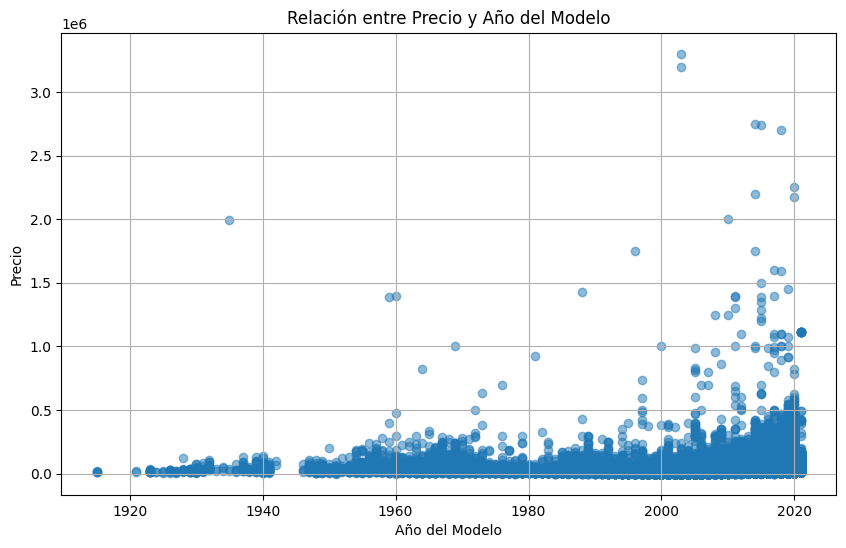

In [141]:
query_year = """
SELECT year, price
FROM CARROS
WHERE year IS NOT NULL AND price IS NOT NULL
"""

data_year = conexion.query(query_year).df()

plt.figure(figsize=(10, 6))
plt.scatter(data_year['year'], data_year['price'], alpha=0.5)
plt.title('Relación entre Precio y Año del Modelo')
plt.xlabel('Año del Modelo')
plt.ylabel('Precio')
plt.grid(True)
plt.show()


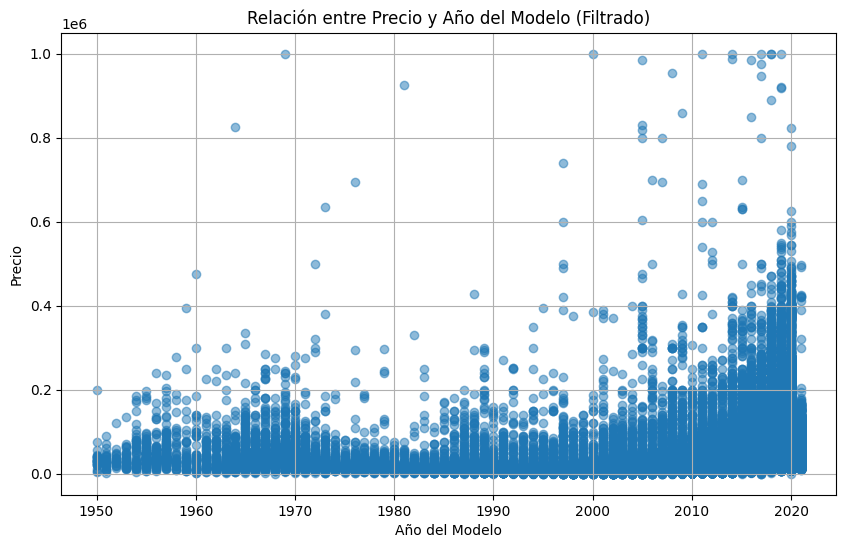

In [142]:
# Filtrar vehículos fabricados después de 1950 y con precios menores a 1 millón
data_filtered_year = data_year[(data_year['year'] >= 1950) & (data_year['price'] < 1000000)]

plt.figure(figsize=(10, 6))
plt.scatter(data_filtered_year['year'], data_filtered_year['price'], alpha=0.5)
plt.title('Relación entre Precio y Año del Modelo (Filtrado)')
plt.xlabel('Año del Modelo')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

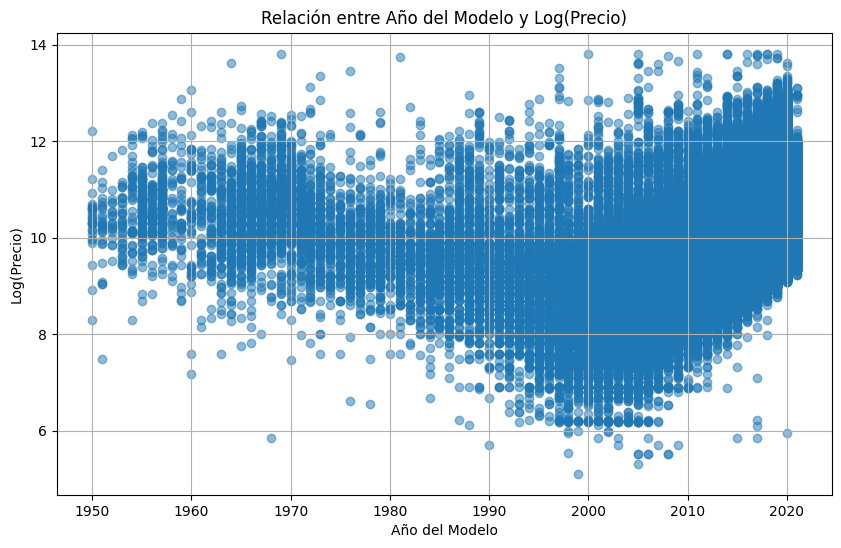

In [143]:
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(data_filtered_year['year'], np.log1p(data_filtered_year['price']), alpha=0.5)
plt.title('Relación entre Año del Modelo y Log(Precio)')
plt.xlabel('Año del Modelo')
plt.ylabel('Log(Precio)')
plt.grid(True)
plt.show()

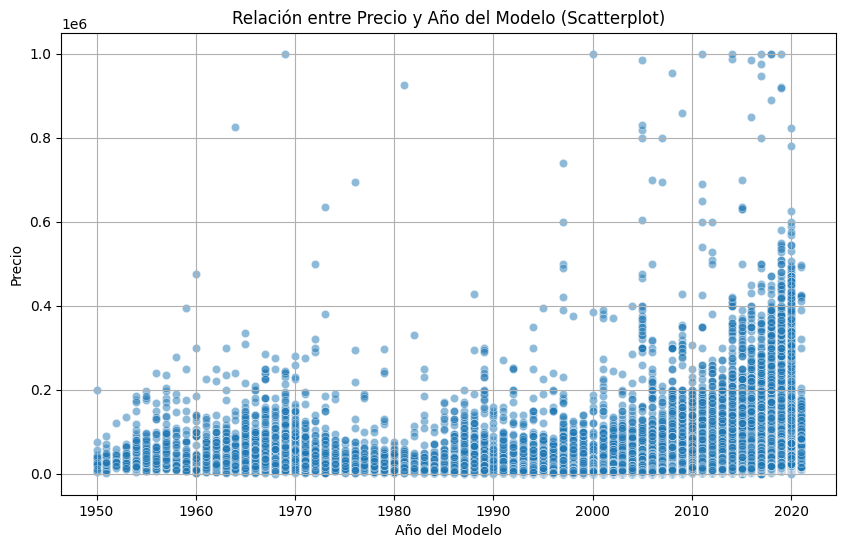

In [144]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='year', y='price', data=data_filtered_year, alpha=0.5)
plt.title('Relación entre Precio y Año del Modelo (Scatterplot)')
plt.xlabel('Año del Modelo')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

C:\Users\alexm\AppData\Local\Temp\ipykernel_39136\56885658.py:2: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




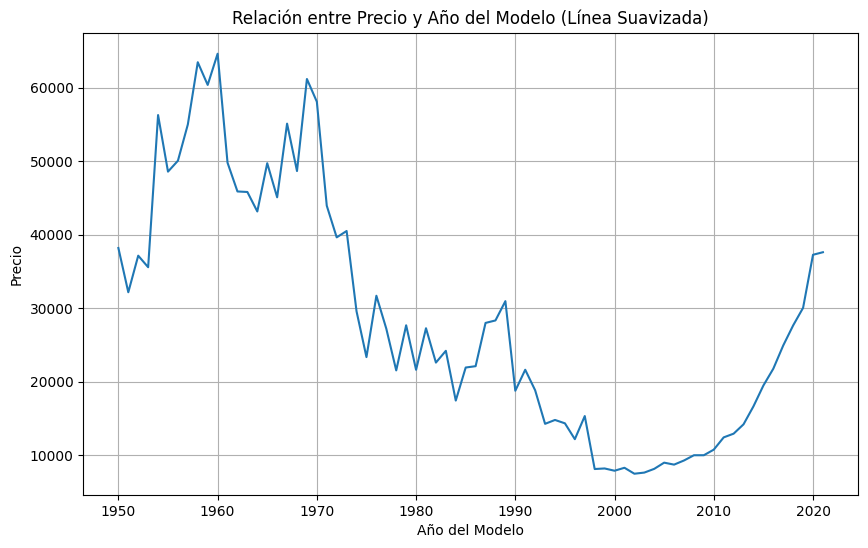

In [145]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='price', data=data_filtered_year, ci=None)
plt.title('Relación entre Precio y Año del Modelo (Línea Suavizada)')
plt.xlabel('Año del Modelo')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

* Años 1950-1960: Observas que los precios parecen estar en su punto más alto en los vehículos de esta época. Esto podría deberse a que algunos de estos vehículos son considerados clásicos y han ganado valor con el tiempo.

* Declinación desde 1960-1980: Hay una tendencia decreciente en los precios de los vehículos fabricados entre 1960 y 1980. Esto puede reflejar que los autos de esa era no han mantenido tanto su valor en comparación con los vehículos clásicos más antiguos.

* Estabilización y Recuperación (1980-2000): Después de 1980, los precios parecen estabilizarse, y alrededor del año 2000, comienza una tendencia ascendente. Esta recuperación podría reflejar la apreciación de vehículos más recientes, mejores tecnologías, y mayor demanda.

* Reciente Aumento de Precios (2000-2020): En los últimos años, desde 2000 en adelante, ves una tendencia clara de aumento en los precios. Esto puede estar relacionado con el valor creciente de los vehículos modernos debido a las mejoras en tecnología, eficiencia, seguridad, y la demanda de modelos más nuevos.

# Clustering


Clustering con scikit-learn para comprobar

In [61]:
!pip install scikit-learn

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     -------------------- ------------------- 30.7/60.8 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 60.8/60.8 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.0 MB 2.6 MB/s eta 0:00:05
   - -------------------------------------- 0.3/11.0 MB 3.8 MB/s eta 0:00:03
   -- ------------------------------------- 0.6/11.0 MB 4.4 MB/s eta 0:00:03
   ---- ----------------------------------- 1.1/11.0 MB 6.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.7/11.0 MB 7.7 MB/s eta 0:00:02
   --------- ------------------------------ 2.5/11.0 MB 9.3 MB/s eta 0:00:01
   ----------- ---------------------------- 3.2/11.0 MB 10.1 MB/s eta 0:00:01
   ------------- -------------------------- 3.8/11.0 MB 10.5 MB/s eta 0:00:01
   ---------------- ----------------------- 4.5/11.0 MB 11.0 MB/s eta 0:00:01
  


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
query_clustering = """
SELECT make_name, model_name,mileage, year, price, horsepower, city_fuel_economy, highway_fuel_economy
FROM CARROS
WHERE mileage IS NOT NULL 
AND make_name IS NOT NULL 
AND model_name IS NOT NULL
AND year IS NOT NULL 
AND price IS NOT NULL 
AND horsepower IS NOT NULL 
AND city_fuel_economy IS NOT NULL 
AND highway_fuel_economy IS NOT NULL
"""

data_clustering = conexion.query(query_clustering).df()

data_clustering

,make_name,model_name,mileage,year,price,horsepower,city_fuel_economy,highway_fuel_economy
0,Jeep,Renegade,7.000000,2019,23141.0,177.0,22.69325,29.47337
1,Land Rover,Discovery Sport,8.000000,2020,46500.0,246.0,22.69325,29.47337
2,Subaru,WRX STI,31146.899743,2016,46995.0,305.0,17.00000,23.00000
3,Land Rover,Discovery,11.000000,2020,67430.0,340.0,22.69325,29.47337
4,Land Rover,Discovery Sport,7.000000,2020,48880.0,246.0,22.69325,29.47337
...,...,...,...,...,...,...,...,...
3000035,Chevrolet,Equinox,41897.000000,2018,17998.0,170.0,26.00000,32.00000
3000036,Chevrolet,Traverse,5.000000,2020,36490.0,310.0,18.00000,27.00000
3000037,Ford,Fusion,57992.000000,2016,12990.0,240.0,22.69325,29.47337
3000038,Jaguar,XE,27857.000000,2017,26998.0,180.0,30.00000,40.00000


In [53]:
data_clustering = data_clustering.dropna()

In [54]:
data_clustering.to_csv("data_clustering.csv", index=False)

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clustering)


In [63]:
import pandas as pd

data_scaled_df = pd.DataFrame(data_scaled, columns=data_clustering.columns)
print(data_scaled_df.head())


    mileage      year     price  horsepower  city_fuel_economy  \
0 -0.427924  0.304325 -0.347149   -0.808342       1.764516e-15   
1 -0.427910  0.543634  0.846698   -0.022723       1.764516e-15   
2  0.000000 -0.413601  0.871997    0.649039      -7.069124e-01   
3 -0.427869  0.543634  1.916402    1.047542       1.764516e-15   
4 -0.427924  0.543634  0.968336   -0.022723       1.764516e-15   

   highway_fuel_economy  
0          1.000105e-15  
1          1.000105e-15  
2         -9.111413e-01  
3          1.000105e-15  
4          1.000105e-15  


In [64]:
from sklearn.cluster import KMeans

# Definimos 4 clusters (puedes ajustar este número según tus necesidades)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Añadimos los clusters al DataFrame original
data_clustering['cluster'] = clusters


C:\Users\alexm\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


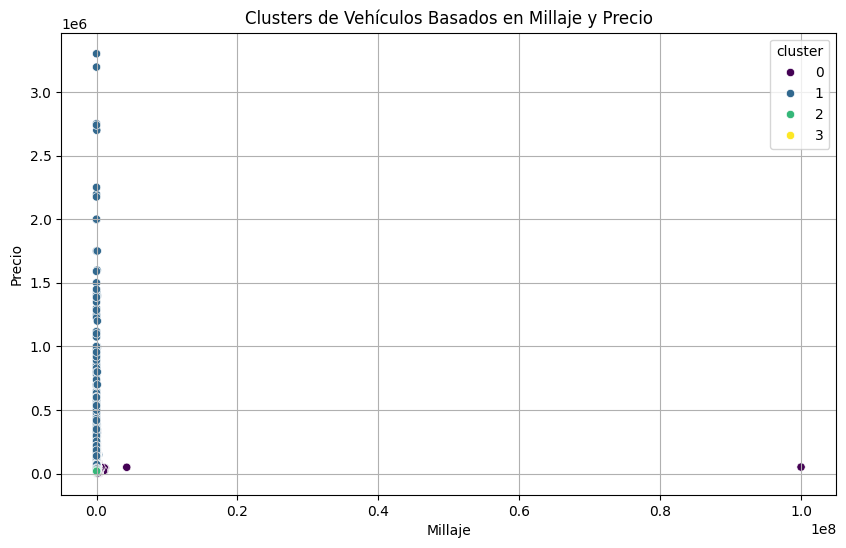

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='mileage', y='price', hue='cluster', data=data_clustering, palette='viridis')
plt.title('Clusters de Vehículos Basados en Millaje y Precio')
plt.xlabel('Millaje')
plt.ylabel('Precio')
plt.grid(True)
plt.show()

C:\Users\alexm\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


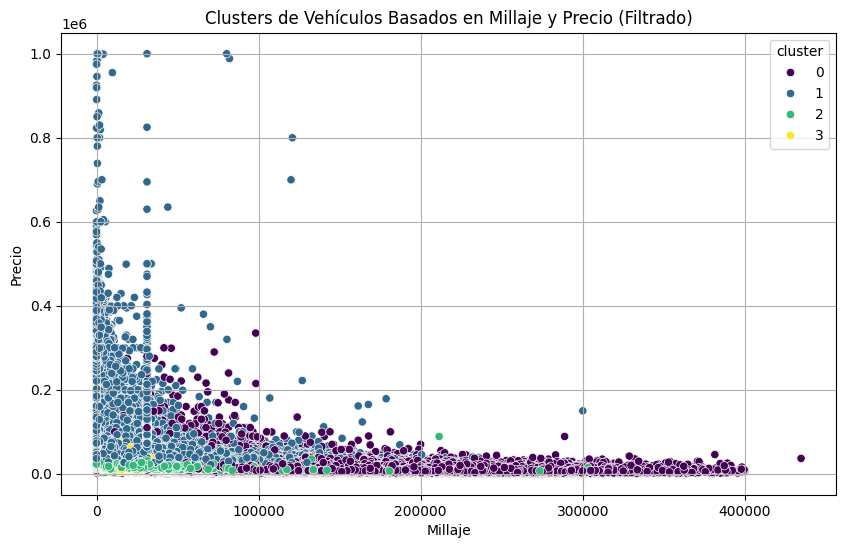

In [66]:
# Filtrar outliers extremos en millaje y precio
data_clustering_filtered = data_clustering[(data_clustering['mileage'] < 500000) & (data_clustering['price'] < 1000000)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='mileage', y='price', hue='cluster', data=data_clustering_filtered, palette='viridis')
plt.title('Clusters de Vehículos Basados en Millaje y Precio (Filtrado)')
plt.xlabel('Millaje')
plt.ylabel('Precio')
plt.grid(True)
plt.show()


C:\Users\alexm\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


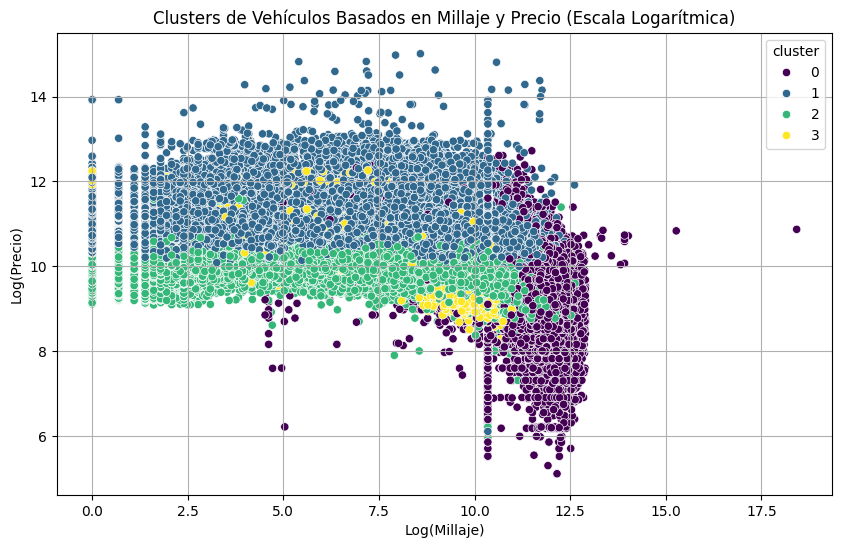

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=np.log1p(data_clustering['mileage']), y=np.log1p(data_clustering['price']), hue='cluster', data=data_clustering, palette='viridis')
plt.title('Clusters de Vehículos Basados en Millaje y Precio (Escala Logarítmica)')
plt.xlabel('Log(Millaje)')
plt.ylabel('Log(Precio)')
plt.grid(True)
plt.show()

* Segmentación del Mercado: La separación en clusters, particularmente en la escala logarítmica, sugiere que hay distintos segmentos de mercado, desde autos más económicos y usados hasta vehículos de mayor valor y posiblemente de lujo.

* Análisis de Vehículos de Nicho: El cluster 3, que es pequeño, podría representar un nicho de mercado con vehículos que tienen un alto valor a pesar de un millaje relativamente alto.


In [68]:
# Resumen estadístico por cluster
cluster_summary = data_clustering_filtered.groupby('cluster').agg({
    'mileage': ['mean', 'median', 'std'],
    'price': ['mean', 'median', 'std'],
    'year': ['mean', 'median', 'std'],
    'horsepower': ['mean', 'median', 'std'],
    'city_fuel_economy': ['mean', 'median', 'std'],
    'highway_fuel_economy': ['mean', 'median', 'std']
}).reset_index()

# Mostrar el resumen
print(cluster_summary)


  cluster        mileage                                 price           \
                    mean    median           std          mean   median   
0       0  116159.376075  110745.0  45883.650608  12255.364977  10900.0   
1       1   15402.212644      43.0  22051.897093  43616.871624  40431.0   
2       2   19211.417705    3774.0  25448.860039  22691.532764  22156.0   
3       3   13189.090112      35.0  18469.767292  42255.358569  34898.0   

                        year                    horsepower             \
            std         mean  median       std        mean     median   
0   8169.966941  2009.968983  2011.0  6.153339  249.238240  247.99571   
1  19863.951130  2019.145808  2020.0  1.552678  324.171797  302.00000   
2   7093.360275  2018.835049  2020.0  1.794157  177.471961  176.00000   
3  34114.771375  2018.554782  2020.0  1.888047  249.205739  247.99571   

             city_fuel_economy                   highway_fuel_economy         \
         std              mean

C:\Users\alexm\AppData\Local\Temp\ipykernel_4912\269470960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='mileage', data=data_clustering_filtered, palette='viridis')


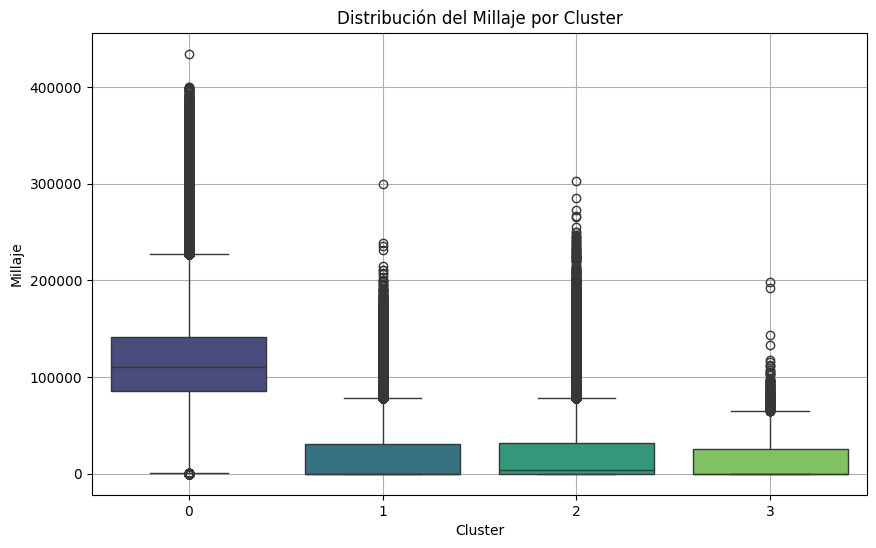

In [69]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='mileage', data=data_clustering_filtered, palette='viridis')
plt.title('Distribución del Millaje por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Millaje')
plt.grid(True)
plt.show()


C:\Users\alexm\AppData\Local\Temp\ipykernel_4912\867844312.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='price', data=data_clustering_filtered, palette='viridis')


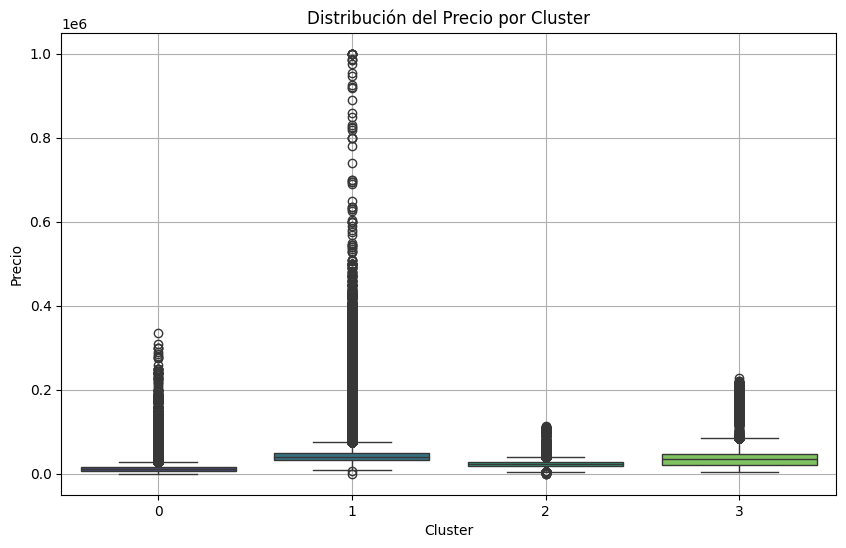

In [70]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='price', data=data_clustering_filtered, palette='viridis')
plt.title('Distribución del Precio por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Precio')
plt.grid(True)
plt.show()


C:\Users\alexm\AppData\Local\Temp\ipykernel_4912\2767540098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='year', data=data_clustering_filtered, palette='viridis')


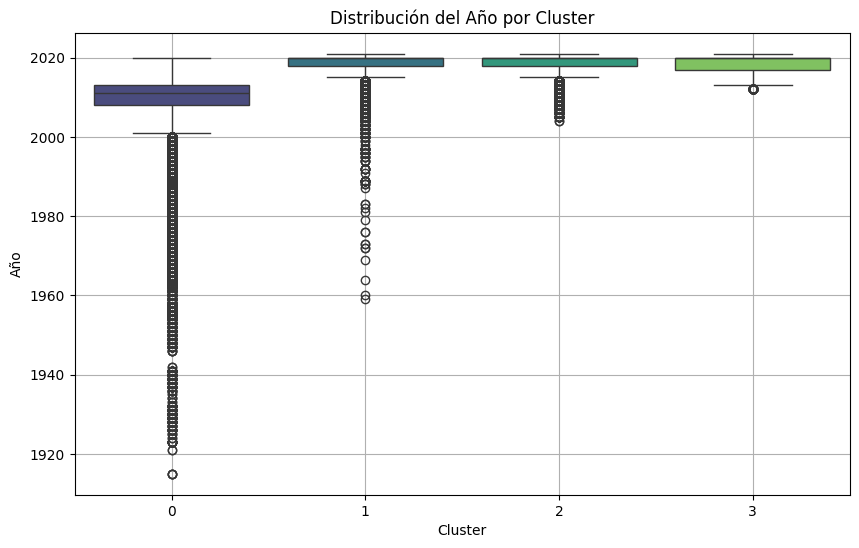

In [71]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='year', data=data_clustering_filtered, palette='viridis')
plt.title('Distribución del Año por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Año')
plt.grid(True)
plt.show()


clustering en SPARK

PREDICCION DE PRECIOS EN PANDAS Y LUEGO A SPARK. 

### Clustering usando Spark

Esta parte lo hicimos en google colab porque no nos corria pyspark en la computadora :(

In [72]:
!pip install pyspark

     ---------------------------------------- 0.0/317.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/317.3 MB 1.9 MB/s eta 0:02:46
     ---------------------------------------- 0.1/317.3 MB 1.4 MB/s eta 0:03:40
     ---------------------------------------- 0.4/317.3 MB 3.0 MB/s eta 0:01:45
     ---------------------------------------- 0.7/317.3 MB 3.8 MB/s eta 0:01:24
     ---------------------------------------- 1.0/317.3 MB 4.3 MB/s eta 0:01:13
     ---------------------------------------- 1.2/317.3 MB 4.4 MB/s eta 0:01:12
     ---------------------------------------- 1.4/317.3 MB 4.4 MB/s eta 0:01:13
     ---------------------------------------- 1.5/317.3 MB 4.2 MB/s eta 0:01:15
     ---------------------------------------- 1.7/317.3 MB 4.2 MB/s eta 0:01:16
     ---------------------------------------- 1.8/317.3 MB 4.1 MB/s eta 0:01:17
     ---------------------------------------- 2.0/317.3 MB 4.0 MB/s eta 0:01:20
     ---------------------------------------- 2

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Python310\\share'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
pip install --upgrade pyspark

  Using cached pyspark-3.5.2-py2.py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: 'c:\\Python310\\Scripts\\beeline'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip
